In [1]:
import jax
jax.config.update("jax_default_matmul_precision", "highest")
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import Array, Float, Int, Bool, UInt32
from functools import partial
import numpy as onp

# ParallelMALA sampler class
from parallel_samplers import ParallelMALA

# miscellaneous
import sys, os
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
import time

/tmp/ipykernel_65207/3206481453.py:15: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# 1. Defining our Log-Posterior and Initializing our RNG Keys

In [2]:
# settings: batch-size (# of chains in parallel) and chain_length (# of samples per chain).
b, chain_length = 4, 16384
max_iters, window_size = chain_length, chain_length # setting window_size = chain_length corresponds to <no sliding window>

# load in the whitened data for bayesian logistic regression (BLR, german credit)
X, y = jnp.asarray(onp.loadtxt("data/X.txt")), jnp.asarray(onp.loadtxt("data/y.txt"))

# BLR prior variance + dimensionality of our data, orthogonal basis transformation Q
sigma_blr, d, Q = 1.0, 25, jnp.load("Q.npy")

# our target logp function
def logp(beta: Float[Array, "d"]) -> Float[Array, ""]:
    d = beta.shape[0]
    logits = X @ beta

    lp = (
        -0.5 * jnp.sum((beta / sigma_blr) ** 2)
        - d * jnp.log(sigma_blr)
        - 0.5 * d * jnp.log(2.0 * jnp.pi)
    )
    lp += jnp.sum(y * logits - jnp.logaddexp(0.0, logits))
    return lp

# what is the stepsize for MALA
epsilon = 0.0015

# sample some initial conditions + our RNG keys
key = jr.PRNGKey(858); k0, kn, ku, kh = jr.split(key, 4)
x0s = 0.1 * jr.normal(k0, shape=(b, d))
xs_init = jnp.tile(x0s[:,None,:], reps=(1, chain_length, 1))
keys_norm = jr.split(kn, b*chain_length).reshape((b, chain_length, 2))
keys_unif = jr.split(ku, b*chain_length).reshape((b, chain_length, 2))
keys_hutchinson = jr.split(kh, b*chain_length).reshape((b, chain_length, 2))

# get the logp + gradient eval, batch via vmap
logp_and_grad = jax.value_and_grad(logp)
logp_and_grad_batched = jax.vmap(fun=logp_and_grad, in_axes=0, out_axes=0)

# 2. Initializing our ParallelMALA Class and Generating Samples

In [3]:
# initialize our ParallelMALA wrapper class
model = ParallelMALA(
    dim=d, epsilon=epsilon, beta=1.0, n_probes=2, basis_transformation=Q, 
    damp_factor=1.0, clip_val=1e8, atol=1e-4, rtol=1e-3
)

In [4]:
# no. of warm-up + timing runs, each.
n_trials = 5

# a. do a few warmup runs
for _ in tqdm(range(n_trials), desc="Warmup"):

    # returns samples + (no. of Newton iterations needed for convergence, per chain)
    outputs_par = model.sample(
        x0s=x0s, xs_init=xs_init, 
        keys_norm=keys_norm, keys_unif=keys_unif, keys_hutchinson=keys_hutchinson, 
        logp_and_grad_batched=logp_and_grad_batched, 
        chain_length=chain_length, window_size=window_size, 
        full_trace=False, max_iters=max_iters
    )
    samples_par, iters_par = jax.block_until_ready(outputs_par)

# a. do the timing runs
start = time.time()
for _ in tqdm(range(n_trials), desc="Timing"):

    # returns samples + (no. of Newton iterations needed for convergence, per chain)
    outputs_par = model.sample(
        x0s=x0s, xs_init=xs_init, 
        keys_norm=keys_norm, keys_unif=keys_unif, keys_hutchinson=keys_hutchinson, 
        logp_and_grad_batched=logp_and_grad_batched, 
        chain_length=chain_length, window_size=window_size, 
        full_trace=False, max_iters=max_iters
    )
    samples_par, iters_par = jax.block_until_ready(outputs_par)
end = time.time()

# how long did each trial take on average?
avg_time = (end - start) / n_trials
max_iters_needed = int(iters_par.max())

# show our results
print(f"#### Batch-size: {b}, Chain-length: {chain_length}")
print(f"Parallel MALA converged in {avg_time:.3f} seconds with {max_iters_needed} quasi-Newton iterations.")

Timing: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.05it/s]

#### Batch-size: 4, Chain-length: 16384
Parallel MALA converged in 0.489 seconds with 76 quasi-Newton iterations.


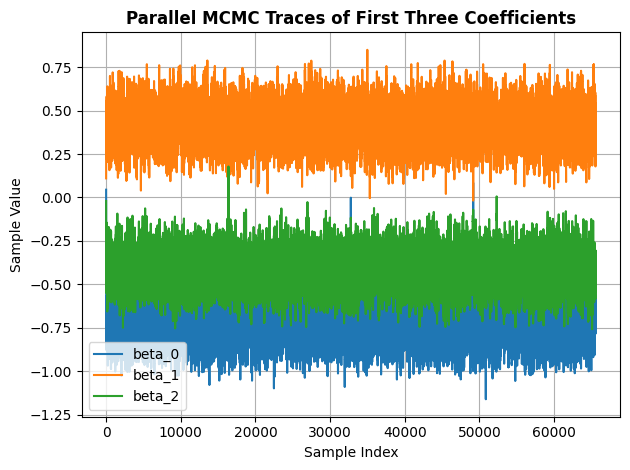

In [5]:
# looking at what the samples look like
b = "b"

# let's look at the first three coordinates of the \beta coefficient vector.
plt.title("Parallel MCMC Traces of First Three Coefficients", fontweight="bold")
plt.plot(samples_par[:,:,:3].reshape(-1, 3), label=["beta_0", "beta_1", "beta_2"])
plt.xlabel("Sample Index"); plt.ylabel("Sample Value"); plt.grid()
plt.legend(); plt.tight_layout()
plt.show()